In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions.one_hot_categorical as one_hot_sample

import queuetorch.env as env
from queuetorch.env import QueuingNetwork
import yaml
from tqdm import trange

import numpy as np
import matplotlib.pyplot as plt

In [4]:
name = 'multiclass'
with open(f'../configs/env/{name}.yaml', 'r') as f:
    env_config = yaml.safe_load(f)

In [5]:
dq = env.load_env(env_config, temp = 0.1, batch = 1, seed = 23, device = 'cpu')

In [6]:
priority = torch.zeros((1,dq.q)).float()
sum_priority = priority.clone()

train_seed = 42

priority.requires_grad = True
alpha = 0.1
num_iter = 50
st_steps = [priority.detach()]
avg_iterate = [sum_priority.clone()]
num = 1


for i in range(num_iter):
    # Calculate gradient
    dq = env.load_env(env_config, temp = 0.00001, batch = 1, seed = 23, device = 'cpu')

    if i > 0:
        obs, state = dq.reset(seed = train_seed, init_queues = init_queues)
    else:
        obs, state = dq.reset(seed = train_seed)
    total_cost = torch.tensor([[0.]]*dq.batch)
    
    
    for _ in trange(1000):
        queues, time = obs
        
        pr = F.softmax(priority.repeat(dq.batch,dq.s,1), -1) * dq.network
        pr = torch.minimum(pr, queues.unsqueeze(1).repeat(1, dq.s, 1))
        pr += 1*torch.all(pr == 0., dim = 2).reshape(dq.batch,dq.s,1) * dq.network
        pr /= torch.sum(pr, dim = -1).reshape(dq.batch, dq.s, 1) 
        
        action = pr
        obs, state, cost, event_time = dq.step(state, action)
        total_cost += cost

    init_queues = queues.detach()
    avg_cost = torch.mean(total_cost / state.time)
    avg_cost.backward()

    print(f'priority: {priority}')
    print(f'avg_cost: {avg_cost}')

    normalized_grad = priority.grad / torch.linalg.norm(priority.grad)
    #normalized_grad = priority.grad
    
    priority = priority.detach() - alpha * normalized_grad
    print(f'grad: {normalized_grad}')
    print()
    
    st_steps.append(priority.detach())
    sum_priority += priority.detach()
    num += 1
    avg_iterate.append(sum_priority.clone() / num)
    
    priority.requires_grad = True
    

100%|██████████| 1000/1000 [00:01<00:00, 676.61it/s]


priority: tensor([[0., 0., 0., 0., 0.]], requires_grad=True)
avg_cost: 18.252519607543945
grad: tensor([[-0.5893,  0.1477,  0.6646, -0.3981,  0.1752]])



100%|██████████| 1000/1000 [00:01<00:00, 816.12it/s]


priority: tensor([[ 0.0589, -0.0148, -0.0665,  0.0398, -0.0175]], requires_grad=True)
avg_cost: 22.22060775756836
grad: tensor([[-0.5433, -0.3806,  0.0157,  0.1827,  0.7255]])



100%|██████████| 1000/1000 [00:01<00:00, 812.39it/s]


...

priority: tensor([[ 1.4063,  0.8436, -0.0856, -0.7459, -1.4184]], requires_grad=True)
avg_cost: 12.37396240234375
grad: tensor([[-0.0261, -0.6858,  0.3693, -0.2374,  0.5800]])



100%|██████████| 1000/1000 [00:01<00:00, 828.85it/s]


priority: tensor([[ 1.4089,  0.9122, -0.1225, -0.7221, -1.4764]], requires_grad=True)
avg_cost: 11.877957344055176
grad: tensor([[-0.3404,  0.3151,  0.4824,  0.2445, -0.7017]])



100%|██████████| 1000/1000 [00:01<00:00, 798.43it/s]


priority: tensor([[ 1.4430,  0.8807, -0.1708, -0.7466, -1.4063]], requires_grad=True)
avg_cost: 18.7790584564209
grad: tensor([[-0.8080, -0.0010,  0.5009, -0.0021,  0.3101]])



In [7]:
st_steps_l = torch.stack(avg_iterate)[:,0,:]

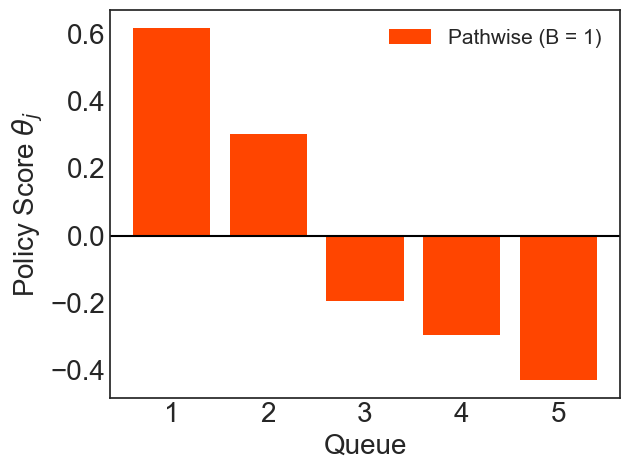

In [8]:
k = 30
plt.style.use('seaborn-v0_8-white')
plt.bar([f'{i}' for i in range(1,1+len(st_steps_l[k]))], st_steps_l[k], color = 'orangered', label = 'Pathwise (B = 1)')
plt.axhline(0, color = 'black')
plt.ylabel(r'Policy Score $\theta_{j}$', fontsize = 20)
plt.xlabel('Queue', fontsize = 20)
plt.yticks(fontsize = 20)
plt.xticks(fontsize = 20)
plt.legend(fontsize = 15)

plt.tight_layout()
#plt.savefig('./plot/cmu_bar_q_5_value.png',dpi = 300)
plt.show()